## Traitement des images

à faire : 
- cropper 30 pixels de chaque côté
- augmenter le niveau de noir du background
- centrer sur le sein
- couper en train / val / test

In [1]:
import sys
import os
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm

# skimage / filters / morphology / io / color / measure
from skimage import filters, morphology, exposure, util, color
from skimage.filters import threshold_otsu, sobel, gaussian
from skimage.restoration import denoise_bilateral
from skimage.segmentation import active_contour
from skimage.io import imread
from skimage.color import rgb2gray
from skimage.measure import label as sk_label

# scipy.ndimage helpers (label alias kept as nd_label where used)
from scipy.ndimage import (binary_fill_holes, gaussian_filter1d,
                           binary_erosion, binary_dilation, label as nd_label)

# torch / torchvision (used in training cells)
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms

In [2]:
print(sys.executable)

c:\Users\Invite\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
# Utilitaire: crop des bords (30 px par défaut)
def crop_borders(img, pad=30):
    if img is None:
        return None
    if isinstance(img, np.ndarray):
        if img.ndim == 2:
            h, w = img.shape
            if h <= 2*pad or w <= 2*pad:
                return img.copy()
            return img[pad:h-pad, pad:w-pad]
        elif img.ndim == 3:
            h, w, _ = img.shape
            if h <= 2*pad or w <= 2*pad:
                return img.copy()
            return img[pad:h-pad, pad:w-pad, :]
    # Fallback pour objets type PIL
    try:
        arr = np.array(img)
    except Exception:
        return img
    return crop_borders(arr, pad)

In [4]:
def get_mask_of_largest_connected_component(mask: np.ndarray) -> np.ndarray:
    lab, n = nd_label(mask.astype(bool))
    if n == 0:
        return np.zeros_like(mask, dtype=bool)
    counts = np.bincount(lab.ravel())
    counts[0] = 0
    return lab == counts.argmax()

def get_edge_values(img: np.ndarray, mask: np.ndarray, axis: str):
    assert axis in ("x", "y")
    h, w = img.shape[:2]
    if axis == "y":
        rows = np.where(mask.any(axis=1))[0]
        y_top = int(rows.min()) if rows.size else 0
        y_bottom = int(rows.max()+1) if rows.size else h
        return y_top, y_bottom
    else:
        cols = np.where(mask.any(axis=0))[0]
        x_left = int(cols.min()) if cols.size else 0
        x_right = int(cols.max()+1) if cols.size else w
        return x_left, x_right

def get_bottommost_pixels(img: np.ndarray, mask: np.ndarray, y_edge_bottom: int):
    if y_edge_bottom <= 0:
        return 0, np.array([], dtype=int)
    y = int(y_edge_bottom - 1)
    xs = np.where(mask[y])[0]
    return y, xs

def include_buffer_y_axis(img: np.ndarray, y_top: int, y_bottom: int, buffer_size: int):
    h = img.shape[0]
    y_top = max(0, int(y_top - buffer_size))
    y_bottom = min(h, int(y_bottom + buffer_size))
    if y_top >= y_bottom:
        y_top, y_bottom = 0, h
    return y_top, y_bottom

def get_distance_from_starting_side(img: np.ndarray, mode: str, x_left: int, x_right: int):
    mask = (img > 0)
    col_sum = mask.sum(axis=0)
    nz = np.where(col_sum > 0)[0]
    if nz.size == 0:
        return 0
    if mode == "left":
        return int(nz[0])
    else:
        w = img.shape[1]
        return int((w - 1) - nz[-1])

def include_buffer_x_axis(img: np.ndarray, mode: str, x_left: int, x_right: int, buffer_size: int):
    w = img.shape[1]
    x_left = max(0, int(x_left - buffer_size))
    x_right = min(w, int(x_right + buffer_size))
    if x_left >= x_right:
        x_left, x_right = 0, w
    return x_left, x_right

def convert_bottommost_pixels_wrt_cropped_image(mode: str, bottom_y: int, bottom_xs: np.ndarray,
                                                 y_edge_top: int, x_edge_right: int, x_edge_left: int):
    h_c = None  # not needed here
    w_c = int(x_edge_right - x_edge_left)
    y_c = int(bottom_y - y_edge_top)
    xs_c = (bottom_xs - x_edge_left).astype(int)
    xs_c = xs_c[(xs_c >= 0) & (xs_c < w_c)]
    if mode == "right" and w_c > 0:
        xs_c = (w_c - 1) - xs_c
    return y_c, xs_c

def get_rightmost_pixels_wrt_cropped_image(mode: str, cropped_mask: np.ndarray, find_rightmost_from_ratio: float):
    h, w = cropped_mask.shape[:2]
    start_y = int(max(0, min(h - 1, np.floor(h * (1.0 - float(find_rightmost_from_ratio))))))
    m = cropped_mask if mode == "left" else np.fliplr(cropped_mask)
    ys = []
    xs_right = []
    for y in range(start_y, h):
        if m[y].any():
            ys.append(y)
            xs_right.append(np.max(np.where(m[y])[0]))
    if len(ys) == 0:
        return np.array([start_y]), 0
    y_start, y_end = int(min(ys)), int(max(ys))
    x_right = int(max(xs_right))
    return np.array([y_start, y_end]), x_right

# --- Required API ---
def crop_img_from_largest_connected(img, mode, erode_dialate=True, iterations=100,
                                    buffer_size=50, find_rightmost_from_ratio=1/3):
    """
    Performs erosion on the mask of the image, selects largest connected component,
    dilates it back, and computes a buffered crop and key points.

    Returns: (window_location, rightmost_points, bottommost_points, distance_from_starting_side)
    """
    assert mode in ("left", "right")
    assert img.ndim == 2, "img must be 2D grayscale"
    img_mask = img > 0
    if erode_dialate and iterations > 0:
        img_mask = binary_erosion(img_mask, iterations=iterations)
    largest_mask = get_mask_of_largest_connected_component(img_mask)
    if erode_dialate and iterations > 0:
        largest_mask = binary_dilation(largest_mask, iterations=iterations)

    y_edge_top, y_edge_bottom = get_edge_values(img, largest_mask, "y")
    x_edge_left, x_edge_right = get_edge_values(img, largest_mask, "x")

    bottommost_nonzero_y, bottommost_nonzero_x = get_bottommost_pixels(img, largest_mask, y_edge_bottom)
    y_edge_top, y_edge_bottom = include_buffer_y_axis(img, y_edge_top, y_edge_bottom, buffer_size)
    distance_from_starting_side = get_distance_from_starting_side(img, mode, x_edge_left, x_edge_right)
    x_edge_left, x_edge_right = include_buffer_x_axis(img, mode, x_edge_left, x_edge_right, buffer_size)

    # convert bottommost pixel locations w.r.t. cropped image. Flip if necessary.
    bottommost_nonzero_y, bottommost_nonzero_x = convert_bottommost_pixels_wrt_cropped_image(
        mode,
        bottommost_nonzero_y,
        bottommost_nonzero_x,
        y_edge_top,
        x_edge_right,
        x_edge_left
    )

    # rightmost from bottom portion (on cropped mask)
    cropped_mask = largest_mask[y_edge_top: y_edge_bottom, x_edge_left: x_edge_right]
    rightmost_nonzero_y, rightmost_nonzero_x = get_rightmost_pixels_wrt_cropped_image(
        mode, cropped_mask, find_rightmost_from_ratio
    )

    window_location = (y_edge_top, y_edge_bottom, x_edge_left, x_edge_right)
    rightmost_points = ((int(rightmost_nonzero_y[0]), int(rightmost_nonzero_y[-1])), int(rightmost_nonzero_x))
    bottommost_points = (int(bottommost_nonzero_y),
                         (int(bottommost_nonzero_x[0]) if bottommost_nonzero_x.size else 0,
                          int(bottommost_nonzero_x[-1]) if bottommost_nonzero_x.size else 0))
    return window_location, rightmost_points, bottommost_points, int(distance_from_starting_side)

def image_orientation(horizontal_flip, side):
    assert horizontal_flip in ['YES', 'NO'], "Wrong horizontal flip"
    assert side in ['L', 'R'], "Wrong side"
    if horizontal_flip == 'YES':
        return 'right' if side == 'R' else 'left'
    else:
        return 'left' if side == 'R' else 'right'

# --- Batch APIs (placeholders: require external project I/O utilities) ---
def crop_mammogram(input_data_folder, exam_list_path, cropped_exam_list_path, output_data_folder,
                   num_processes, num_iterations, buffer_size):
    raise NotImplementedError("This function depends on project-specific I/O (pickling, data_handling, Pool).")

def crop_mammogram_one_image(scan, input_file_path, output_file_path, num_iterations, buffer_size):
    raise NotImplementedError("This function depends on reading_images/saving_images utilities.")

def crop_mammogram_one_image_short_path(scan, input_data_folder, output_data_folder,
                                        num_iterations, buffer_size):
    raise NotImplementedError("This function depends on project-specific path layout.")

Niveaux de gris

In [5]:
def transformation_intensite(img, T, max_int=255):
    table = np.array([T(i) for i in range(max_int+1)]).clip(0, max_int).astype(np.uint8)
    img_transformee = cv2.LUT(img, table)  # Applique la fonction à chaque pixel
    return img_transformee


In [6]:
def min_max_scale_grayscale(grayscale_image):
    # convert to numpy array
    img_array = np.array(grayscale_image).astype(np.float32)
    # min-max scaling
    min_val = img_array.min()
    max_val = img_array.max()
    if max_val - min_val == 0:
        # avoid division by zero : return black image or same image
        scaled_array = np.zeros_like(img_array, dtype=np.uint8)
    else:
        scaled_array = ((img_array - min_val) / (max_val - min_val) * 255).astype(np.uint8)
    return scaled_array

In [7]:
def compute_mean_std(image_paths):
    n_pixels = 0
    channel_sum = 0.0
    channel_sum_squared = 0.0

    for img_path in tqdm(image_paths):
        img=cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
        #Add a channel dimension for consistency (H, W, C)
        img = np.expand_dims(img, axis=-1)
        #Accumulate sums
        n_pixels += (img.shape[0] * img.shape[1])
        channel_sum += np.sum(img, axis=(0, 1))
        channel_sum_squared += np.sum(img**2, axis=(0, 1))

    #Compute mean and std
    mean = channel_sum / n_pixels
    std = np.sqrt((channel_sum_squared / n_pixels) - (mean ** 2))
    return mean, std

In [8]:
image_path = r"C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\Cancer\0001\C_0001_1.LEFT_CC.png"

dataset_dir = os.path.dirname(os.path.dirname(image_path))

# Lister des images PNG du dataset (avec échantillonnage pour accélérer si nécessaire)
all_pngs = glob(os.path.join(dataset_dir, "**", "*.png"), recursive=True)
sample_n = min(500, len(all_pngs))  # ajuster au besoin
image_paths = random.sample(all_pngs, sample_n) if sample_n > 0 else [image_path]

# Statistiques globales du dataset
mean_u8, std_u8 = compute_mean_std(image_paths)
mean_u8 = float(np.atleast_1d(mean_u8)[0])
std_u8 = float(np.maximum(np.atleast_1d(std_u8)[0], 1e-6))
print(f"Dataset mean={mean_u8:.3f}, std={std_u8:.3f} (échelle 0-255), sur {len(image_paths)} images")

img_gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
img_gray = crop_borders(img_gray, pad=30)

# Normalisation basée dataset: z-score, puis remise à l'échelle [0,1] pour compatibilité avec le reste du pipeline
img_z = (img_gray - mean_u8) / std_u8
img01 = (img_z - img_z.min()) / max(img_z.max() - img_z.min(), 1e-6)

# Sorties attendues par les cellules suivantes
img_uint8 = (img01 * 255).astype(np.uint8)   # uint8 [0,255]
image = img01.astype(np.float32)              # float [0,1]

100%|██████████| 500/500 [00:25<00:00, 19.78it/s]

Dataset mean=28.827, std=48.350 (échelle 0-255), sur 500 images


CLAHE sauvegardé : C:\Users\Invite\Documents\INRIA\MCDropout\archive\MINI-DDSM-Complete-PNG-16\Cancer\0001\C_0001_1.LEFT_CC_clahe.png


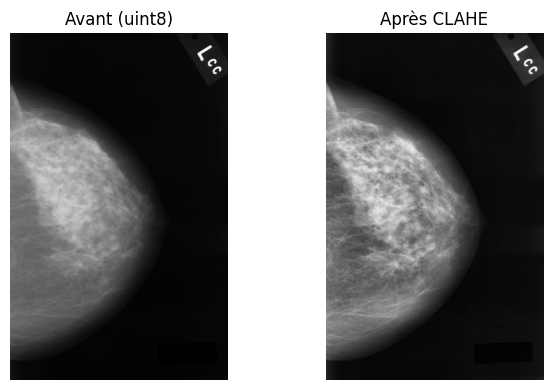

In [9]:
# Assurer uint8 mono-canal à partir de `image` ou réutiliser `img_uint8` existant
try:
    img_uint8
except NameError:
    if np.issubdtype(image.dtype, np.floating):
        img_uint8 = (np.clip(image, 0.0, 1.0) * 255).astype(np.uint8)
    elif image.dtype == np.uint16:
        lo, hi = np.percentile(image, (1, 99.5))
        img_uint8 = ((np.clip(image, lo, hi) - lo) / max(hi - lo, 1e-6) * 255).astype(np.uint8)
    else:
        img_uint8 = image.astype(np.uint8)

# Paramètres CLAHE
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
img_clahe = clahe.apply(img_uint8)

# Version float [0,1] si besoin pour la suite du pipeline
image_clahe = img_clahe.astype(np.float32) / 255.0

# Sauvegarde près de l'image source
base = os.path.splitext(os.path.basename(image_path))[0]
out_path = os.path.join(os.path.dirname(image_path), f"{base}_clahe.png")
cv2.imwrite(out_path, img_clahe)
print("CLAHE sauvegardé :", out_path)

# Affichage avant/après
fig, axes = plt.subplots(1, 2, figsize=(7, 4))
axes[0].imshow(img_uint8, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Avant (uint8)")
axes[0].axis('off')
axes[1].imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Après CLAHE")
axes[1].axis('off')
plt.tight_layout(); plt.show()

In [ ]:
# Parameters and mask logic (imports moved to top consolidated cell)
 # Paramètres
thr_scale = 0.6      # < 1.0 => seuil plus bas qu’Otsu (masque plus large)
min_size = 2000
closing_r = 7
dilation_r = 20
use_convex_hull = True

# Flou pour stabiliser le seuil
blur = gaussian(image, sigma=2.0, preserve_range=True)

# Otsu sur les pixels > 0
nz = blur[image > 0]
thr_otsu = threshold_otsu(nz) if nz.size else 0.02
thr_low = max(0.005, thr_otsu * thr_scale, np.percentile(nz, 1) if nz.size else 0.01)

def postprocess(mask, do_dilate=True):
    mask = morphology.remove_small_objects(mask, min_size=min_size)
    mask = binary_fill_holes(mask)
    mask = morphology.binary_closing(mask, morphology.disk(closing_r))
    lab = sk_label(mask, connectivity=1)
    if lab.max() > 0:
        counts = np.bincount(lab.ravel()); counts[0] = 0
        mask = (lab == counts.argmax())
    if use_convex_hull:
        mask = morphology.convex_hull_image(mask)
    if do_dilate and dilation_r > 0:
        mask = morphology.binary_dilation(mask, morphology.disk(dilation_r))
    return mask

# --- NEW: expand mask helper to add margin in percent around the largest component bbox ---
def expand_mask_by_margin(mask: np.ndarray, margin_pct: float = 0.05) -> np.ndarray:
    """
    Expand mask by a percentage of its bounding box size.
    margin_pct: fraction (e.g. 0.05 = 5%) applied on bbox width/height.
    """
    if margin_pct is None or margin_pct <= 0:
        return mask
    h, w = mask.shape[:2]
    ys, xs = np.where(mask)
    if xs.size == 0:
        return mask
    x0, x1 = int(xs.min()), int(xs.max())
    y0, y1 = int(ys.min()), int(ys.max())
    bw = x1 - x0 + 1
    bh = y1 - y0 + 1
    dx = int(round(bw * float(margin_pct)))
    dy = int(round(bh * float(margin_pct)))
    x0n = max(0, x0 - dx)
    x1n = min(w, x1 + dx + 1)
    y0n = max(0, y0 - dy)
    y1n = min(h, y1 + dy + 1)
    new_mask = np.zeros_like(mask, dtype=bool)
    new_mask[y0n:y1n, x0n:x1n] = True
    # smooth a bit to avoid sharp corners
    rad = max(1, int(round(max(dx, dy) * 0.5)))
    try:
        return morphology.binary_dilation(new_mask, morphology.disk(rad))
    except Exception:
        # fallback: simple dilation with scipy if morphology.disk unavailable
        from scipy.ndimage import binary_dilation
        return binary_dilation(new_mask, iterations=max(1, rad))

# 1) Variante stricte (masque d'Otsu exact, sans élargissement)
mask_strict = postprocess(blur > thr_otsu, do_dilate=False)

# 2) Variante combinée (au moins aussi large que l’un des deux)
mask_combined = postprocess((blur > thr_low) | (blur > thr_otsu), do_dilate=True)

# 3) Variante “Otsu élargi” (Otsu + dilatation)
mask_otsu_dil = postprocess(blur > thr_otsu, do_dilate=True)

extra_dilation_r = 150 
if extra_dilation_r and extra_dilation_r > 0:
    try:
        mask_otsu_dil = morphology.binary_dilation(mask_otsu_dil, morphology.disk(int(extra_dilation_r)))
    except Exception:
        from scipy.ndimage import binary_dilation
        mask_otsu_dil = binary_dilation(mask_otsu_dil, iterations=int(extra_dilation_r))

# create an expanded mask to give a margin around the breast
margin_pct = 0.05  # <-- ajuster ici en pourcentage (0.05 = 5%)
mask_combined_expanded = expand_mask_by_margin(mask_combined, margin_pct=margin_pct)

def apply_mask(u8img, mask):
    out = u8img.copy()
    out[~mask] = 0
    return out

img_strict = apply_mask(img_clahe, mask_strict)
img_combined = apply_mask(img_clahe, mask_combined_expanded)  # use expanded mask for downstream
img_otsu_dil = apply_mask(img_clahe, mask_otsu_dil)

# Visualisation: lignes = [masques, images masquées], colonnes = [stricte, combinée, Otsu élargi]
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes[0,0].imshow(mask_strict, cmap='gray');  axes[0,0].set_title("Masque Otsu strict");   axes[0,0].axis('off')
axes[0,1].imshow(mask_combined, cmap='gray');axes[0,1].set_title("Masque combiné");       axes[0,1].axis('off')
axes[0,2].imshow(mask_otsu_dil, cmap='gray');axes[0,2].set_title("Masque Otsu élargi");   axes[0,2].axis('off')

axes[1,0].imshow(img_strict, cmap='gray', vmin=0, vmax=255);  axes[1,0].set_title("CLAHE + Otsu strict");  axes[1,0].axis('off')
axes[1,1].imshow(img_combined, cmap='gray', vmin=0, vmax=255);axes[1,1].set_title("CLAHE + combiné");      axes[1,1].axis('off')
axes[1,2].imshow(img_otsu_dil, cmap='gray', vmin=0, vmax=255);axes[1,2].set_title("CLAHE + Otsu élargi");  axes[1,2].axis('off')
plt.tight_layout(); plt.show()

# Stats
pct0_old = 100.0 * (img_clahe == 0).mean()
pct0_strict = 100.0 * (img_strict == 0).mean()
pct0_combined = 100.0 * (img_combined == 0).mean()
pct0_otsu_dil = 100.0 * (img_otsu_dil == 0).mean()
print(f"Pixels à 0 (CLAHE): {pct0_old:.2f}% | Otsu strict: {pct0_strict:.2f}% | combiné: {pct0_combined:.2f}% | Otsu élargi: {pct0_otsu_dil:.2f}%")
print(f"Otsu={thr_otsu:.4f} | thr_low={thr_low:.4f} | thr_scale={thr_scale}")

On garde Otsu combiné (à discuter)

Mode estimé: right
Crop window (estimée): (239, 2123, 0, 964) | distance_from_starting_side: 490
Crop window (fixe demandé): (181, 2181, 0, 1400) | distance_from_starting_side: 490
Taille recadrée (avant réduction) : (1400, 2000)
Taille recadrée (après réduction) : (700, 1000)


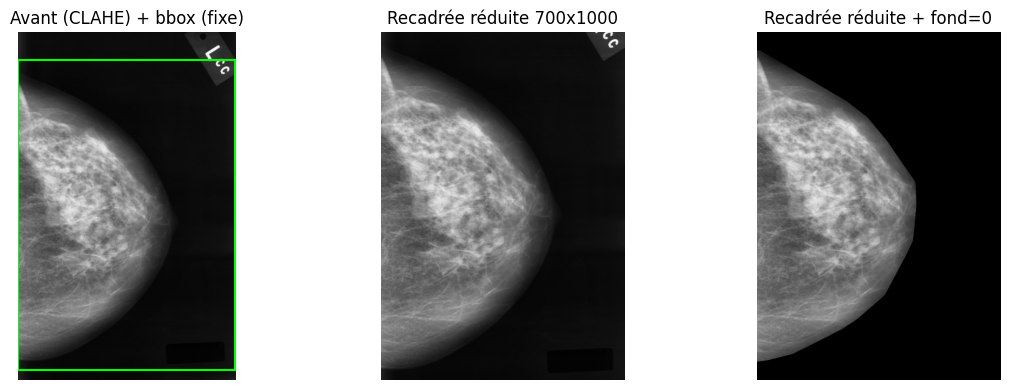

In [ ]:
# Appliquer le crop basé sur la plus grande composante de l'image gardée (mask combiné)
def _guess_mode_from_mask(mask: np.ndarray) -> str:
    h, w = mask.shape[:2]
    cols = np.where(mask.any(axis=0))[0]
    if cols.size == 0:
        return 'left'
    left_gap = int(cols[0])
    right_gap = int((w - 1) - cols[-1])
    return 'right' if left_gap <= right_gap else 'left'

mode = _guess_mode_from_mask(mask_otsu_dil.astype(bool))
print('Mode estimé:', mode)

win_loc, rightmost_pts, bottommost_pts, dist_side = crop_img_from_largest_connected(
    img=img_otsu_dil,
    mode=mode,
    erode_dialate=True,
    iterations=20,
    buffer_size=50,
    find_rightmost_from_ratio=1/3
)
y_top, y_bot, x_left, x_right = win_loc
print('Crop window (estimée):', win_loc, '| distance_from_starting_side:', dist_side)

# --- Fixed output size (modifiable) ---
target_h = 2000   # hauteur souhaitée avant downscale
target_w = 1400   # largeur souhaitée avant downscale

H, W = img_clahe.shape[:2]

# centre de la fenêtre calculée
y_c = (y_top + y_bot) // 2
x_c = (x_left + x_right) // 2

# calculer nouvelles bornes centrées, en veillant aux bords
y0 = int(max(0, y_c - target_h // 2))
y1 = int(min(H, y0 + target_h))
if (y1 - y0) < target_h:
    y0 = int(max(0, y1 - target_h))

x0 = int(max(0, x_c - target_w // 2))
x1 = int(min(W, x0 + target_w))
if (x1 - x0) < target_w:
    x0 = int(max(0, x1 - target_w))

# si l'image est plus petite que la taille cible, utiliser l'image entière
if H < target_h:
    y0, y1 = 0, H
if W < target_w:
    x0, x1 = 0, W

new_win_loc = (y0, y1, x0, x1)
print('Crop window (fixe demandé):', new_win_loc, '| distance_from_starting_side:', dist_side)

# Créer des sorties recadrées cohérentes pour la suite du pipeline (taille forcée si possible)
img_kept_cropped = img_clahe[y0:y1, x0:x1]                    # uint8 CLAHE recadrée
mask_kept_cropped = mask_otsu_dil[y0:y1, x0:x1]      # utiliser masque élargi
image_kept_cropped = image[y0:y1, x0:x1]                      # float[0,1] recadrée

print("Taille recadrée (avant réduction) :", img_kept_cropped.shape[::-1])  # (W, H) affiché

# Optionnel: remettre à zéro le fond en utilisant le masque recadré (safe)
img_kept_cropped_bg0 = img_kept_cropped.copy()
try:
    mm = mask_kept_cropped.astype(bool)
    if mm.shape == img_kept_cropped.shape:
        img_kept_cropped_bg0[~mm] = 0
    else:
        hmin = min(mm.shape[0], img_kept_cropped.shape[0])
        wmin = min(mm.shape[1], img_kept_cropped.shape[1])
        img_kept_cropped_bg0[:hmin, :wmin][~mm[:hmin, :wmin]] = 0
except Exception:
    pass

# --- Downscale final output (divide size by 2 while keeping content) ---
final_scale = 0.5  # 0.5 -> moitié largeur/hauteur ; changer si besoin
if final_scale != 1.0 and img_kept_cropped.size:
    # compute new size (width, height) for cv2.resize
    Hc, Wc = img_kept_cropped.shape[:2]
    new_w = max(1, int(round(Wc * final_scale)))
    new_h = max(1, int(round(Hc * final_scale)))

    # resize uint8 image and bg0 using area interpolation for downscaling
    img_kept_cropped_small = cv2.resize(img_kept_cropped, (new_w, new_h), interpolation=cv2.INTER_AREA)
    img_kept_cropped_bg0_small = cv2.resize(img_kept_cropped_bg0, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # resize mask with nearest to preserve binary nature
    try:
        mask_u8 = (mask_kept_cropped.astype(np.uint8) * 255)
        mask_small_u8 = cv2.resize(mask_u8, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
        mask_kept_cropped_small = (mask_small_u8 > 127)
    except Exception:
        mask_kept_cropped_small = None

    # resize float image (image_kept_cropped) with INTER_AREA and keep float range
    try:
        imgf = (image_kept_cropped * 255.0).astype(np.uint8) if image_kept_cropped.dtype != np.uint8 else image_kept_cropped
        imgf_small_u8 = cv2.resize(imgf, (new_w, new_h), interpolation=cv2.INTER_AREA)
        image_kept_cropped_small = imgf_small_u8.astype(np.float32) / 255.0
    except Exception:
        image_kept_cropped_small = None

    print("Taille recadrée (après réduction) :", (new_w, new_h))

else:
    img_kept_cropped_small = img_kept_cropped.copy()
    img_kept_cropped_bg0_small = img_kept_cropped_bg0.copy()
    mask_kept_cropped_small = mask_kept_cropped.copy()
    image_kept_cropped_small = image_kept_cropped.copy()
    print("Aucune réduction appliquée (final_scale=1)")

# Visualisation rapide (affiche la version réduite)
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_clahe, cmap='gray', vmin=0, vmax=255)
axes[0].add_patch(plt.Rectangle((x0, y0), x1 - x0, y1 - y0,
                               fill=False, edgecolor='lime', linewidth=1.5))
axes[0].set_title('Avant (CLAHE) + bbox (fixe)')
axes[0].axis('off')

axes[1].imshow(img_kept_cropped_small, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Recadrée réduite {img_kept_cropped_small.shape[1]}x{img_kept_cropped_small.shape[0]}')
axes[1].axis('off')

axes[2].imshow(img_kept_cropped_bg0_small, cmap='gray', vmin=0, vmax=255)
axes[2].set_title('Recadrée réduite + fond=0')
axes[2].axis('off')

plt.tight_layout(); plt.show()

## Entraînement

Normalisation